# Day 05 — Model Optimization
## Sampling Strategies × Threshold Tuning × TimeSeriesSplit CV × Optuna

**Steps:**
1. Ingestion + Pipeline (from scratch)
2. Compare 7 sampling strategies
3. TimeSeriesSplit cross-validation
4. Selected strategy: **RandomOverSampler** — hyperparameter optimization with Optuna

### Split design
```
Gold (sorted by time_6h)
├── Train  80%
│   ├── Fit set   first 85%  ← sampling + model training
│   └── Val set   last  15%  ← threshold tuning (raw, no resample)
└── Test   20%  ────────────── final evaluation (never touched)

CV (Optuna): TimeSeriesSplit(n_splits=5), ROS applied inside each training fold
```

---
## 0. Setup

In [28]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, fbeta_score,
    precision_score, recall_score, precision_recall_curve,
    classification_report,
)
from xgboost import XGBClassifier
import joblib

print("Core libraries ready.")

Core libraries ready.


In [29]:
# imbalanced-learn
try:
    import imblearn
    print(f"imbalanced-learn {imblearn.__version__}")
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    import imblearn
    print(f"Installed imbalanced-learn {imblearn.__version__}")

from imblearn.over_sampling  import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine        import SMOTETomek
from imblearn.pipeline       import Pipeline as ImbPipeline

# optuna
try:
    import optuna
    print(f"optuna {optuna.__version__}")
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna
    print(f"Installed optuna {optuna.__version__}")

print("All libraries ready.")

imbalanced-learn 0.14.1
optuna 4.8.0
All libraries ready.


---
## 1. Ingestion & Pipeline

In [30]:
from src import ingestion, config

print(f"Date range : {config.HISTORICAL_START}  →  {config.HISTORICAL_END}")
print(f"Zones      : {[z['zone'] for z in config.BAKU_ZONES]}")
print()
print("Running historical ingestion (Bronze)...")
ingestion.run_historical_ingest()
print("Done.")

Date range : 2020-01-01  →  2026-04-20
Zones      : ['High Relief', 'Low Relief', 'Moderate Relief']

Running historical ingestion (Bronze)...
Done.


In [31]:
from src import pipeline

print("Building Silver → Gold...")
pipeline.run_pipeline()
print("Done.")

df = pipeline.load_gold()
print(f"\nGold: {df.shape[0]:,} rows  x  {df.shape[1]} columns")
df.head(3)

Building Silver → Gold...
Done.

Gold: 27,624 rows  x  39 columns


,zone,time_6h,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_temperature_0_to_7cm,et0_fao_evapotranspiration,...,humidity_precip_product,highland_precip_24h,zone_cascade_risk,hour_sin,hour_cos,doy_sin,doy_cos,is_winter,dq_score,is_flood
0,High Relief,2020-01-01 00:00:00,4.050000,96.666667,0.0,7.950000,0.227833,0.259,5.166667,0.00,...,0.0,0.0,0.0,0.000000e+00,1.000000e+00,0.017213,0.999852,1,1.0,0
1,High Relief,2020-01-01 06:00:00,3.983333,81.833333,0.0,7.433333,0.228000,0.259,3.816667,0.17,...,0.0,0.0,0.0,1.000000e+00,6.123234e-17,0.017213,0.999852,1,1.0,0
2,High Relief,2020-01-01 12:00:00,10.233333,68.000000,0.0,8.816667,0.224167,0.259,10.466667,0.84,...,0.0,0.0,0.0,1.224647e-16,-1.000000e+00,0.017213,0.999852,1,1.0,0


---
## 2. Class Imbalance

In [32]:
TARGET     = "is_flood"
counts     = df[TARGET].value_counts().sort_index()
flood_rate = df[TARGET].mean()

print(f"Total rows     : {len(df):,}")
print(f"Flood events   : {counts.get(1, 0):,}   ({flood_rate*100:.2f}%)")
print(f"Non-flood      : {counts.get(0, 0):,}  ({(1-flood_rate)*100:.2f}%)")
print(f"Imbalance ratio: 1 : {(1-flood_rate)/max(flood_rate, 1e-9):.0f}")
print("\nFlood rate by zone:")
print((df.groupby("zone")[TARGET].mean() * 100).round(2).to_string())

Total rows     : 27,624
Flood events   : 293   (1.06%)
Non-flood      : 27,331  (98.94%)
Imbalance ratio: 1 : 93

Flood rate by zone:
zone
High Relief        0.40
Low Relief         2.42
Moderate Relief    0.36


---
## 3. Feature Preparation & Splits

In [33]:
from src.model import prepare_features, _time_split

train_df, test_df = _time_split(df, test_frac=0.20)

X_train_raw, feature_cols = prepare_features(train_df)
X_test_raw,  _            = prepare_features(test_df)
for c in feature_cols:
    if c not in X_test_raw.columns:
        X_test_raw[c] = 0
X_test_raw = X_test_raw[feature_cols]

y_train = train_df[TARGET].values
y_test  = test_df[TARGET].values
X_train = X_train_raw.fillna(0).values
X_test  = X_test_raw.fillna(0).values

print(f"Features : {len(feature_cols)}")
print(f"Train    : {X_train.shape}   flood rate = {y_train.mean()*100:.2f}%")
print(f"Test     : {X_test.shape}    flood rate = {y_test.mean()*100:.2f}%")

Features : 27
Train    : (22098, 27)   flood rate = 0.62%
Test     : (5526, 27)    flood rate = 2.82%


In [34]:
# Validation window carved from the end of train — never resampled, used only for threshold tuning
val_cut = int(len(X_train) * 0.85)
X_tr,  y_tr  = X_train[:val_cut], y_train[:val_cut]
X_val, y_val = X_train[val_cut:], y_train[val_cut:]

print(f"Fit set  : {X_tr.shape}   flood rate = {y_tr.mean()*100:.2f}%")
print(f"Val set  : {X_val.shape}  flood rate = {y_val.mean()*100:.2f}%")
print(f"Test set : {X_test.shape}  flood rate = {y_test.mean()*100:.2f}%")

Fit set  : (18783, 27)   flood rate = 0.65%
Val set  : (3315, 27)  flood rate = 0.45%
Test set : (5526, 27)  flood rate = 2.82%


---
## 4. Helper Functions

In [35]:
# scale_pos_weight removed — each sampling strategy handles imbalance independently
BASE_XGB_PARAMS = dict(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 5,
    min_child_weight = 3,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    eval_metric      = "aucpr",
    random_state     = 42,
    n_jobs           = -1,
)

# Recall-biased threshold: maximize F2-score (beta=2 weights recall 4x over precision)
# min_precision floor prevents the threshold from collapsing to 0 and predicting everything as flood
def best_threshold_for_recall(model, X, y, beta=2.0, min_precision=0.05):
    probs = model.predict_proba(X)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y, probs)
    fbeta = ((1 + beta**2) * precision * recall
             / (beta**2 * precision + recall + 1e-9))
    # Enforce minimum precision floor on the threshold candidates
    valid = precision[:-1] >= min_precision
    if valid.any():
        masked = np.where(valid, fbeta[:-1], -1.0)
        return float(thresholds[np.argmax(masked)])
    # Fallback: no threshold meets min_precision — take best F2 anyway
    return float(thresholds[np.argmax(fbeta[:-1])])


def evaluate(model, X, y, threshold, name=""):
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)
    return {
        "Strategy" : name,
        "AUC-ROC"  : round(roc_auc_score(y, probs), 4),
        "AUC-PR"   : round(average_precision_score(y, probs), 4),
        "F1"       : round(f1_score(y, preds, zero_division=0), 4),
        "F2"       : round(fbeta_score(y, preds, beta=2, zero_division=0), 4),
        "Precision": round(precision_score(y, preds, zero_division=0), 4),
        "Recall"   : round(recall_score(y, preds, zero_division=0), 4),
        "Threshold": round(threshold, 4),
    }, probs


def run_strategy(name, sampler, params=None):
    """Resample fit set, train XGB, tune threshold for recall (F2), evaluate on test."""
    xgb_params = params if params else BASE_XGB_PARAMS
    if sampler is not None:
        X_s, y_s = sampler.fit_resample(X_tr, y_tr)
    else:
        X_s, y_s = X_tr, y_tr

    print(f"\n{'─'*58}")
    print(f"  {name}")
    print(f"  Fit rows : {X_s.shape[0]:,}   flood rate = {y_s.mean()*100:.1f}%")

    mdl = XGBClassifier(**xgb_params)
    mdl.fit(X_s, y_s, eval_set=[(X_val, y_val)], verbose=False)

    threshold      = best_threshold_for_recall(mdl, X_val, y_val)
    metrics, probs = evaluate(mdl, X_test, y_test, threshold, name)

    print(f"  Threshold (F2-tuned) : {threshold:.4f}")
    print(f"  AUC-ROC  = {metrics['AUC-ROC']:.4f}")
    print(f"  AUC-PR   = {metrics['AUC-PR']:.4f}")
    print(f"  F2       = {metrics['F2']:.4f}   "
          f"F1 = {metrics['F1']:.4f}   "
          f"Precision = {metrics['Precision']:.4f}   "
          f"Recall = {metrics['Recall']:.4f}")
    return mdl, threshold, metrics, probs


all_results  = {}
all_probs    = {}
saved_models = {}
print("Helpers ready.")

Helpers ready.


---
## 5. Strategy Comparison
Sampling applied **only** to the fit set. Val and test sets are always raw.

In [36]:
m, t, metrics, probs = run_strategy("Baseline", None)
all_results["Baseline"]  = metrics
all_probs["Baseline"]    = probs
saved_models["Baseline"] = (m, t)


──────────────────────────────────────────────────────────
  Baseline
  Fit rows : 18,783   flood rate = 0.6%
  Threshold (F2-tuned) : 0.1942
  AUC-ROC  = 0.9322
  AUC-PR   = 0.4130
  F2       = 0.3273   F1 = 0.3760   Precision = 0.5000   Recall = 0.3013


In [37]:
m, t, metrics, probs = run_strategy("RandomOverSampler", RandomOverSampler(random_state=42))
all_results["RandomOverSampler"]  = metrics
all_probs["RandomOverSampler"]    = probs
saved_models["RandomOverSampler"] = (m, t)


──────────────────────────────────────────────────────────
  RandomOverSampler
  Fit rows : 37,322   flood rate = 50.0%
  Threshold (F2-tuned) : 0.1546
  AUC-ROC  = 0.9263
  AUC-PR   = 0.4703
  F2       = 0.5109   F1 = 0.4746   Precision = 0.4242   Recall = 0.5385


In [38]:
m, t, metrics, probs = run_strategy("RandomUnderSampler", RandomUnderSampler(random_state=42))
all_results["RandomUnderSampler"]  = metrics
all_probs["RandomUnderSampler"]    = probs
saved_models["RandomUnderSampler"] = (m, t)


──────────────────────────────────────────────────────────
  RandomUnderSampler
  Fit rows : 244   flood rate = 50.0%
  Threshold (F2-tuned) : 0.9929
  AUC-ROC  = 0.9359
  AUC-PR   = 0.2975
  F2       = 0.1274   F1 = 0.1709   Precision = 0.3953   Recall = 0.1090


In [39]:
m, t, metrics, probs = run_strategy("SMOTE", SMOTE(random_state=42, k_neighbors=5))
all_results["SMOTE"]  = metrics
all_probs["SMOTE"]    = probs
saved_models["SMOTE"] = (m, t)


──────────────────────────────────────────────────────────
  SMOTE
  Fit rows : 37,322   flood rate = 50.0%
  Threshold (F2-tuned) : 0.7590
  AUC-ROC  = 0.9282
  AUC-PR   = 0.3580
  F2       = 0.1833   F1 = 0.2336   Precision = 0.4310   Recall = 0.1603


In [40]:
try:
    m, t, metrics, probs = run_strategy("ADASYN", ADASYN(random_state=42))
    all_results["ADASYN"]  = metrics
    all_probs["ADASYN"]    = probs
    saved_models["ADASYN"] = (m, t)
except Exception as exc:
    print(f"\nADASYN skipped — {exc}")


──────────────────────────────────────────────────────────
  ADASYN
  Fit rows : 37,313   flood rate = 50.0%
  Threshold (F2-tuned) : 0.6138
  AUC-ROC  = 0.9270
  AUC-PR   = 0.3529
  F2       = 0.1868   F1 = 0.2281   Precision = 0.3611   Recall = 0.1667


In [41]:
m, t, metrics, probs = run_strategy("TomekLinks", TomekLinks(n_jobs=-1))
all_results["TomekLinks"]  = metrics
all_probs["TomekLinks"]    = probs
saved_models["TomekLinks"] = (m, t)


──────────────────────────────────────────────────────────
  TomekLinks
  Fit rows : 18,723   flood rate = 0.7%
  Threshold (F2-tuned) : 0.1051
  AUC-ROC  = 0.9330
  AUC-PR   = 0.4010
  F2       = 0.4189   F1 = 0.4437   Precision = 0.4922   Recall = 0.4038


In [42]:
m, t, metrics, probs = run_strategy("SMOTETomek", SMOTETomek(random_state=42))
all_results["SMOTETomek"]  = metrics
all_probs["SMOTETomek"]    = probs
saved_models["SMOTETomek"] = (m, t)


──────────────────────────────────────────────────────────
  SMOTETomek
  Fit rows : 37,322   flood rate = 50.0%
  Threshold (F2-tuned) : 0.7590
  AUC-ROC  = 0.9282
  AUC-PR   = 0.3580
  F2       = 0.1833   F1 = 0.2336   Precision = 0.4310   Recall = 0.1603


---
## 6. Cross-Validation — TimeSeriesSplit
Sampling is wrapped inside `imblearn.Pipeline` so it fires only on training folds, never on validation folds.

In [43]:
train_sorted = train_df.sort_values("time_6h").reset_index(drop=True)
X_cv_raw, _  = prepare_features(train_sorted)
for c in feature_cols:
    if c not in X_cv_raw.columns:
        X_cv_raw[c] = 0
X_cv = X_cv_raw[feature_cols].fillna(0).values
y_cv = train_sorted[TARGET].values

tscv = TimeSeriesSplit(n_splits=5)

cv_pipelines = {
    "Baseline"          : ImbPipeline([("clf", XGBClassifier(**BASE_XGB_PARAMS))]),
    "RandomOverSampler" : ImbPipeline([("smp", RandomOverSampler(random_state=42)),
                                       ("clf", XGBClassifier(**BASE_XGB_PARAMS))]),
    "RandomUnderSampler": ImbPipeline([("smp", RandomUnderSampler(random_state=42)),
                                       ("clf", XGBClassifier(**BASE_XGB_PARAMS))]),
    "SMOTE"             : ImbPipeline([("smp", SMOTE(random_state=42, k_neighbors=5)),
                                       ("clf", XGBClassifier(**BASE_XGB_PARAMS))]),
    "TomekLinks"        : ImbPipeline([("smp", TomekLinks(n_jobs=-1)),
                                       ("clf", XGBClassifier(**BASE_XGB_PARAMS))]),
    "SMOTETomek"        : ImbPipeline([("smp", SMOTETomek(random_state=42)),
                                       ("clf", XGBClassifier(**BASE_XGB_PARAMS))]),
}
if "ADASYN" in all_results:
    cv_pipelines["ADASYN"] = ImbPipeline([("smp", ADASYN(random_state=42)),
                                           ("clf", XGBClassifier(**BASE_XGB_PARAMS))])

print(f"CV: TimeSeriesSplit(n_splits=5)   scoring=average_precision")
print(f"Train size: {X_cv.shape[0]:,} rows\n")

cv_results = {}
for name, pipe in cv_pipelines.items():
    try:
        scores = cross_val_score(
            pipe, X_cv, y_cv,
            cv=tscv, scoring="average_precision", n_jobs=-1,
        )
        valid = scores[~np.isnan(scores)]
        cv_results[name] = {
            "mean" : valid.mean() if len(valid) else float("nan"),
            "std"  : valid.std()  if len(valid) else float("nan"),
            "folds": scores,
        }
        print(f"{name:<22s}: AUC-PR = {cv_results[name]['mean']:.4f} "
              f"± {cv_results[name]['std']:.4f}   folds = {np.round(scores, 4)}")
    except Exception as exc:
        print(f"{name:<22s}: FAILED — {exc}")

CV: TimeSeriesSplit(n_splits=5)   scoring=average_precision
Train size: 22,098 rows

Baseline              : AUC-PR = 0.1872 ± 0.1868   folds = [   nan 0.0885 0.5102 0.0875 0.0626]
RandomOverSampler     : AUC-PR = 0.2187 ± 0.2192   folds = [   nan 0.0848 0.5964 0.1272 0.0665]
RandomUnderSampler    : AUC-PR = 0.1576 ± 0.1065   folds = [   nan 0.0446 0.285  0.2406 0.0601]
SMOTE                 : AUC-PR = 0.2089 ± 0.2179   folds = [   nan 0.0231 0.5767 0.1599 0.0758]
TomekLinks            : AUC-PR = 0.1697 ± 0.1540   folds = [   nan 0.0739 0.4356 0.0991 0.07  ]
SMOTETomek            : AUC-PR = 0.2089 ± 0.2179   folds = [   nan 0.0231 0.5767 0.1599 0.0758]
ADASYN                : AUC-PR = 0.1966 ± 0.2014   folds = [   nan 0.0172 0.5344 0.1584 0.0764]


---
## 7. Results Table

In [44]:
results_df = pd.DataFrame(list(all_results.values())).set_index("Strategy")
results_df["CV AUC-PR"] = [
    round(cv_results.get(k, {}).get("mean", float("nan")), 4)
    for k in results_df.index
]
results_df = results_df.sort_values("Recall", ascending=False)

display(
    results_df.style
    .highlight_max(subset=["AUC-ROC", "AUC-PR", "F2", "Recall"], color="#b7e4c7")
    .highlight_min(subset=["F2", "Recall"],                       color="#ffb3b3")
    .format({
        "AUC-ROC"  : "{:.4f}",
        "AUC-PR"   : "{:.4f}",
        "F1"       : "{:.4f}",
        "F2"       : "{:.4f}",
        "Precision": "{:.4f}",
        "Recall"   : "{:.4f}",
        "Threshold": "{:.4f}",
        "CV AUC-PR": "{:.4f}",
    })
    .set_caption("Sorted by Recall. Green = best, Red = worst. F2 = recall-weighted metric.")
)

,AUC-ROC,AUC-PR,F1,F2,Precision,Recall,Threshold,CV AUC-PR
Strategy,,,,,,,,
RandomOverSampler,0.9263,0.4703,0.4746,0.5109,0.4242,0.5385,0.1546,0.2187
TomekLinks,0.9330,0.4010,0.4437,0.4189,0.4922,0.4038,0.1051,0.1697
Baseline,0.9322,0.4130,0.3760,0.3273,0.5000,0.3013,0.1942,0.1872
ADASYN,0.9270,0.3529,0.2281,0.1868,0.3611,0.1667,0.6138,0.1966
SMOTE,0.9282,0.3580,0.2336,0.1833,0.4310,0.1603,0.7590,0.2089
SMOTETomek,0.9282,0.3580,0.2336,0.1833,0.4310,0.1603,0.7590,0.2089
RandomUnderSampler,0.9359,0.2975,0.1709,0.1274,0.3953,0.1090,0.9929,0.1576


---
## 8. RandomOverSampler — Selection Rationale

**Manually selected: RandomOverSampler**

- **Threshold is now tuned by maximizing F2-score** (beta=2) on the val window with `min_precision ≥ 5%`
  — this directly pushes the threshold lower to catch more floods instead of the previous F1-optimal threshold which collapsed to 0.9994 (missing 94% of floods)
- ROS creates a balanced 50/50 fit set, giving the model strong flood signal without destroying the majority class structure
- Among oversampling strategies, ROS + F2 threshold achieves the highest **Recall** and **F2** on the test set
- Missing a real flood is catastrophically more costly than a false alarm → Recall must be the primary metric

In [45]:
# Hardcoded selection — RandomOverSampler
SELECTED = "RandomOverSampler"
sel_model, sel_threshold = saved_models[SELECTED]
sel_metrics = all_results[SELECTED]
sel_probs   = all_probs[SELECTED]
sel_preds   = (sel_probs >= sel_threshold).astype(int)

print(f"Selected strategy : {SELECTED}")
print(f"Threshold         : {sel_threshold:.4f}")
print(f"AUC-ROC           : {sel_metrics['AUC-ROC']:.4f}")
print(f"AUC-PR            : {sel_metrics['AUC-PR']:.4f}")
print(f"F1                : {sel_metrics['F1']:.4f}")
print(f"Precision         : {sel_metrics['Precision']:.4f}")
print(f"Recall            : {sel_metrics['Recall']:.4f}")
print()
print(classification_report(y_test, sel_preds,
                             target_names=["No Flood", "Flood"],
                             zero_division=0))

Selected strategy : RandomOverSampler
Threshold         : 0.1546
AUC-ROC           : 0.9263
AUC-PR            : 0.4703
F1                : 0.4746
Precision         : 0.4242
Recall            : 0.5385

              precision    recall  f1-score   support

    No Flood       0.99      0.98      0.98      5370
       Flood       0.42      0.54      0.47       156

    accuracy                           0.97      5526
   macro avg       0.71      0.76      0.73      5526
weighted avg       0.97      0.97      0.97      5526



---
## 9. Hyperparameter Optimization — Optuna

**Objective:** optimize the RandomOverSampler + XGBoost pipeline using Optuna TPE sampler.

**Strategy:**
- Each trial runs `TimeSeriesSplit(n_splits=5)` internally
- ROS is applied only to each training fold (never to the validation fold)
- Folds with zero positive examples (first fold issue) are skipped; remaining folds are averaged
- **Maximize: F2-score** (beta=2 — recall is weighted 4× more than precision, aligned with flood detection priority)
- Trials: 60

In [46]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

tscv_opt = TimeSeriesSplit(n_splits=5)


def objective(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators",      100, 900),
        "learning_rate"   : trial.suggest_float("learning_rate",   0.005, 0.3,  log=True),
        "max_depth"       : trial.suggest_int("max_depth",         3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight",  1, 15),
        "subsample"       : trial.suggest_float("subsample",       0.4, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree",0.4, 1.0),
        "reg_alpha"       : trial.suggest_float("reg_alpha",       1e-8, 20.0, log=True),
        "reg_lambda"      : trial.suggest_float("reg_lambda",      1e-8, 20.0, log=True),
        "gamma"           : trial.suggest_float("gamma",           0.0, 5.0),
        "eval_metric"     : "aucpr",
        "random_state"    : 42,
        "n_jobs"          : -1,
    }

    fold_scores = []
    for fold_tr_idx, fold_val_idx in tscv_opt.split(X_cv):
        X_f_tr,  y_f_tr  = X_cv[fold_tr_idx],  y_cv[fold_tr_idx]
        X_f_val, y_f_val = X_cv[fold_val_idx], y_cv[fold_val_idx]

        # Skip folds with no positive examples in train or val
        if y_f_tr.sum() < 2 or y_f_val.sum() == 0:
            continue

        X_res, y_res = RandomOverSampler(random_state=42).fit_resample(X_f_tr, y_f_tr)

        mdl = XGBClassifier(**params)
        mdl.fit(X_res, y_res, verbose=False)

        probs = mdl.predict_proba(X_f_val)[:, 1]

        # F2-optimal threshold per fold — aligned with recall priority
        precision_c, recall_c, thresh_c = precision_recall_curve(y_f_val, probs)
        fbeta_c = ((1 + 4) * precision_c * recall_c
                   / (4 * precision_c + recall_c + 1e-9))
        valid_mask = precision_c[:-1] >= 0.05
        if valid_mask.any():
            best_thr = thresh_c[np.argmax(np.where(valid_mask, fbeta_c[:-1], -1.0))]
        else:
            best_thr = thresh_c[np.argmax(fbeta_c[:-1])]

        preds = (probs >= best_thr).astype(int)
        fold_scores.append(fbeta_score(y_f_val, preds, beta=2, zero_division=0))

    return float(np.mean(fold_scores)) if fold_scores else 0.0


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=60, show_progress_bar=True)

print(f"\nOptimization complete.")
print(f"Best CV F2     : {study.best_value:.4f}")
print(f"Best params    :")
for k, v in study.best_params.items():
    print(f"  {k:<22s}: {v}")

Best trial: 54. Best value: 0.490282: 100%|██████████| 60/60 [01:19<00:00,  1.32s/it]


Optimization complete.
Best CV F2     : 0.4903
Best params    :
  n_estimators          : 429
  learning_rate         : 0.017587484829921188
  max_depth             : 5
  min_child_weight      : 15
  subsample             : 0.9195543449421186
  colsample_bytree      : 0.5555297914250537
  reg_alpha             : 1.3133967418217038e-06
  reg_lambda            : 7.058454136368709
  gamma                 : 4.932003804214401


In [47]:
# Trial history — convergence to best F2 value
trial_values = [t.value for t in study.trials if t.value is not None]
best_so_far  = [max(trial_values[:i+1]) for i in range(len(trial_values))]

print("Trial progression (CV F2-score):")
for i, (tv, bsf) in enumerate(zip(trial_values, best_so_far)):
    marker = " <-- new best" if tv == bsf and (i == 0 or bsf > best_so_far[i-1]) else ""
    print(f"  Trial {i+1:>3d}: {tv:.4f}  (best so far: {bsf:.4f}){marker}")

Trial progression (CV F2-score):
  Trial   1: 0.4271  (best so far: 0.4271) <-- new best
  Trial   2: 0.4294  (best so far: 0.4294) <-- new best
  Trial   3: 0.4386  (best so far: 0.4386) <-- new best
  Trial   4: 0.4812  (best so far: 0.4812) <-- new best
  Trial   5: 0.4368  (best so far: 0.4812)
  Trial   6: 0.4413  (best so far: 0.4812)
  Trial   7: 0.4049  (best so far: 0.4812)
  Trial   8: 0.4396  (best so far: 0.4812)
  Trial   9: 0.4317  (best so far: 0.4812)
  Trial  10: 0.4123  (best so far: 0.4812)
  Trial  11: 0.4572  (best so far: 0.4812)
  Trial  12: 0.4559  (best so far: 0.4812)
  Trial  13: 0.4496  (best so far: 0.4812)
  Trial  14: 0.4194  (best so far: 0.4812)
  Trial  15: 0.4262  (best so far: 0.4812)
  Trial  16: 0.4593  (best so far: 0.4812)
  Trial  17: 0.4062  (best so far: 0.4812)
  Trial  18: 0.4610  (best so far: 0.4812)
  Trial  19: 0.4530  (best so far: 0.4812)
  Trial  20: 0.4536  (best so far: 0.4812)
  Trial  21: 0.4364  (best so far: 0.4812)
  Trial  22:

---
## 10. Tuned Model — Final Training & Evaluation

In [48]:
# Attach fixed fields to best params from Optuna
best_params = {
    **study.best_params,
    "eval_metric" : "aucpr",
    "random_state": 42,
    "n_jobs"      : -1,
}

# Resample fit set with ROS, then train with tuned params
X_ros, y_ros = RandomOverSampler(random_state=42).fit_resample(X_tr, y_tr)
print(f"Fit rows (resampled) : {X_ros.shape[0]:,}   flood rate = {y_ros.mean()*100:.1f}%")

tuned_model = XGBClassifier(**best_params)
tuned_model.fit(X_ros, y_ros, eval_set=[(X_val, y_val)], verbose=False)

# F2-optimal threshold on validation window
tuned_threshold        = best_threshold_for_recall(tuned_model, X_val, y_val)
tuned_metrics, tuned_probs = evaluate(tuned_model, X_test, y_test,
                                       tuned_threshold, "ROS + Optuna")
tuned_preds = (tuned_probs >= tuned_threshold).astype(int)

print(f"\nThreshold (F2-tuned) : {tuned_threshold:.4f}")
print(f"AUC-ROC   : {tuned_metrics['AUC-ROC']:.4f}")
print(f"AUC-PR    : {tuned_metrics['AUC-PR']:.4f}")
print(f"F2        : {tuned_metrics['F2']:.4f}")
print(f"F1        : {tuned_metrics['F1']:.4f}")
print(f"Precision : {tuned_metrics['Precision']:.4f}")
print(f"Recall    : {tuned_metrics['Recall']:.4f}")

Fit rows (resampled) : 37,322   flood rate = 50.0%

Threshold (F2-tuned) : 0.4664
AUC-ROC   : 0.9315
AUC-PR    : 0.4244
F2        : 0.4036
F1        : 0.4133
Precision : 0.4306
Recall    : 0.3974


In [49]:
# Base ROS vs Optuna-tuned ROS — side-by-side comparison
base_m = sel_metrics

compare = pd.DataFrame([
    {"Model"    : "ROS  (base params)",
     "AUC-ROC" : base_m["AUC-ROC"],
     "AUC-PR"  : base_m["AUC-PR"],
     "F2"      : base_m["F2"],
     "F1"      : base_m["F1"],
     "Precision": base_m["Precision"],
     "Recall"  : base_m["Recall"],
     "Threshold": base_m["Threshold"]},
    {"Model"    : "ROS  (Optuna tuned)",
     "AUC-ROC" : tuned_metrics["AUC-ROC"],
     "AUC-PR"  : tuned_metrics["AUC-PR"],
     "F2"      : tuned_metrics["F2"],
     "F1"      : tuned_metrics["F1"],
     "Precision": tuned_metrics["Precision"],
     "Recall"  : tuned_metrics["Recall"],
     "Threshold": tuned_metrics["Threshold"]},
]).set_index("Model")

# Delta row
delta = compare.loc["ROS  (Optuna tuned)"] - compare.loc["ROS  (base params)"]
delta.name = "Delta (tuned - base)"
compare = pd.concat([compare, delta.to_frame().T])

display(
    compare.style
    .highlight_max(subset=["AUC-PR", "F2", "Recall"], color="#b7e4c7")
    .format("{:.4f}")
    .set_caption("Base ROS vs Optuna-tuned ROS — test set")
)

print("\nClassification Report — Optuna Tuned Model:")
print(classification_report(y_test, tuned_preds,
                             target_names=["No Flood", "Flood"],
                             zero_division=0))

,AUC-ROC,AUC-PR,F2,F1,Precision,Recall,Threshold
ROS (base params),0.9263,0.4703,0.5109,0.4746,0.4242,0.5385,0.1546
ROS (Optuna tuned),0.9315,0.4244,0.4036,0.4133,0.4306,0.3974,0.4664
Delta (tuned - base),0.0052,-0.0459,-0.1073,-0.0613,0.0064,-0.1411,0.3118



Classification Report — Optuna Tuned Model:
              precision    recall  f1-score   support

    No Flood       0.98      0.98      0.98      5370
       Flood       0.43      0.40      0.41       156

    accuracy                           0.97      5526
   macro avg       0.71      0.69      0.70      5526
weighted avg       0.97      0.97      0.97      5526



---
## 11. Calibration Comparison — Real Held-Out Fold vs Synthetic Folds

**Problem:** `CalibratedClassifierCV` applied after ROS fits isotonic regression on
CV folds that contain **synthetic duplicate points**. Isotonic learns a distorted
probability mapping, collapsing the model's discrimination ability.

**Fix:** a proper **70 / 15 / 15 chronological split** — oversample only the 70%
train portion, calibrate on the real 15% calib fold (zero synthetic points),
evaluate on the real 15% test fold.

Three variants — **same Optuna params, same ROS train set**:

| | Calibration |
|---|---|
| **A** | `CalibratedClassifierCV(isotonic, cv=5)` on synthetic-augmented data *(current)* |
| **B** | None — raw XGBoost probabilities |
| **C** | `IsotonicRegression` on real calib fold only *(proposed)* |


In [52]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss

# 70 / 15 / 15 date-based chronological split
_df = df.sort_values('time_6h').reset_index(drop=True)
_N  = len(_df)
_cut1 = _df.iloc[int(_N * 0.70)]['time_6h']
_cut2 = _df.iloc[int(_N * 0.85)]['time_6h']

tr3_df = _df[_df['time_6h'] <  _cut1]
ca3_df = _df[(_df['time_6h'] >= _cut1) & (_df['time_6h'] < _cut2)]
te3_df = _df[_df['time_6h'] >= _cut2]

def _prep3(src, cols=None):
    X_raw, fc = prepare_features(src)
    if cols:
        for c in cols:
            if c not in X_raw.columns: X_raw[c] = 0
        return X_raw[cols].fillna(0).values, cols
    return X_raw.fillna(0).values, fc

X_tr3, feat3 = _prep3(tr3_df)
X_ca3, _     = _prep3(ca3_df, feat3)
X_te3, _     = _prep3(te3_df, feat3)
y_tr3 = tr3_df[TARGET].values
y_ca3 = ca3_df[TARGET].values
y_te3 = te3_df[TARGET].values

for lbl, X, y, d0, d1 in [
    ('Train (70%)', X_tr3, y_tr3, tr3_df['time_6h'].min(), tr3_df['time_6h'].max()),
    ('Calib (15%)', X_ca3, y_ca3, ca3_df['time_6h'].min(), ca3_df['time_6h'].max()),
    ('Test  (15%)', X_te3, y_te3, te3_df['time_6h'].min(), te3_df['time_6h'].max()),
]:
    print(f"{lbl}: {X.shape[0]:>6} rows  floods={y.sum():>4}  "
          f"rate={y.mean()*100:.2f}%  {d0.date()} → {d1.date()}")


Train (70%):  19335 rows  floods= 122  rate=0.63%  2020-01-01 → 2024-05-30
Calib (15%):   4143 rows  floods=  39  rate=0.94%  2024-05-30 → 2025-05-10
Test  (15%):   4146 rows  floods= 132  rate=3.18%  2025-05-10 → 2026-04-20


In [53]:
X_ros3, y_ros3 = RandomOverSampler(random_state=42).fit_resample(X_tr3, y_tr3)
print(f"Resampled train: {X_ros3.shape}  flood rate={y_ros3.mean()*100:.1f}%\n")

# A — CalibratedClassifierCV on synthetic-augmented data
mdl_a = CalibratedClassifierCV(XGBClassifier(**best_params), method='isotonic', cv=5)
mdl_a.fit(X_ros3, y_ros3)
p_a_ca = mdl_a.predict_proba(X_ca3)[:, 1]
p_a_te = mdl_a.predict_proba(X_te3)[:, 1]
print(f"[A] CalibratedCV   test probs  mean={p_a_te.mean():.4f}  "
      f"p10={np.percentile(p_a_te,10):.4f}  p90={np.percentile(p_a_te,90):.4f}")

# B — raw XGBoost, no calibration
mdl_b = XGBClassifier(**best_params)
mdl_b.fit(X_ros3, y_ros3, eval_set=[(X_ca3, y_ca3)], verbose=False)
p_b_ca = mdl_b.predict_proba(X_ca3)[:, 1]
p_b_te = mdl_b.predict_proba(X_te3)[:, 1]
print(f"[B] Raw XGB        test probs  mean={p_b_te.mean():.4f}  "
      f"p10={np.percentile(p_b_te,10):.4f}  p90={np.percentile(p_b_te,90):.4f}")

# C — Isotonic on real calib fold only
iso_c = IsotonicRegression(out_of_bounds='clip')
iso_c.fit(p_b_ca, y_ca3)
p_c_ca = iso_c.predict(p_b_ca)
p_c_te = iso_c.predict(p_b_te)
print(f"[C] Isotonic ({y_ca3.sum()} real positives)  "
      f"mean={p_c_te.mean():.4f}  "
      f"p10={np.percentile(p_c_te,10):.4f}  p90={np.percentile(p_c_te,90):.4f}")


Resampled train: (38426, 27)  flood rate=50.0%

[A] CalibratedCV   test probs  mean=0.0123  p10=0.0000  p90=0.0000
[B] Raw XGB        test probs  mean=0.0424  p10=0.0004  p90=0.0475
[C] Isotonic (39 real positives)  mean=0.0106  p10=0.0000  p90=0.0250


In [54]:
def _best_thresh3(p, y, beta=2.0, mp=0.05):
    prec, rec, thr = precision_recall_curve(y, p)
    fb = (1+beta**2)*prec*rec / (beta**2*prec+rec+1e-9)
    v = prec[:-1] >= mp
    return float(thr[np.argmax(np.where(v, fb[:-1], -1.))]) if v.any() \
           else float(thr[np.argmax(fb[:-1])])

def _ev3(p, y, thr, name):
    from sklearn.metrics import confusion_matrix
    preds = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    return {
        'Model':     name,
        'AUC-PR':    round(average_precision_score(y, p), 4),
        'AUC-ROC':   round(roc_auc_score(y, p), 4),
        'Brier':     round(brier_score_loss(y, p), 4),
        'F2':        round(fbeta_score(y, preds, beta=2, zero_division=0), 4),
        'Recall':    round(recall_score(y, preds, zero_division=0), 4),
        'Precision': round(precision_score(y, preds, zero_division=0), 4),
        'Threshold': round(thr, 4),
        'TP': tp, 'FP': fp, 'FN': fn,
    }

thr_a = _best_thresh3(p_a_ca, y_ca3)
thr_b = _best_thresh3(p_b_ca, y_ca3)
thr_c = _best_thresh3(p_c_ca, y_ca3)

r_a = _ev3(p_a_te, y_te3, thr_a, 'A  CalibratedCV  (synthetic folds, current)')
r_b = _ev3(p_b_te, y_te3, thr_b, 'B  Raw XGB       (uncalibrated)')
r_c = _ev3(p_c_te, y_te3, thr_c, 'C  Isotonic      (real calib fold)  ★')

cmp3 = pd.DataFrame([r_a, r_b, r_c]).set_index('Model')
delta = (cmp3.loc['C  Isotonic      (real calib fold)  ★']
       - cmp3.loc['A  CalibratedCV  (synthetic folds, current)'])
delta.name = 'Δ  C minus A'
cmp3 = pd.concat([cmp3, delta.to_frame().T])

display(
    cmp3.style
    .highlight_min(subset=['Brier','FN'],                   color='#b7e4c7')
    .highlight_max(subset=['AUC-PR','AUC-ROC','F2','Recall','TP'], color='#b7e4c7')
    .format(lambda v: f'{v:.4f}' if isinstance(v, float) else str(v))
    .set_caption(
        'Calibration comparison — 70/15/15 chronological split, '
        'Optuna params throughout, same ROS train set'
    )
)


,AUC-PR,AUC-ROC,Brier,F2,Recall,Precision,Threshold,TP,FP,FN
"A CalibratedCV (synthetic folds, current)",0.2986,0.7010,0.0282,0.4199,0.4091,0.4696,0.0027,54.0000,61.0000,78.0000
B Raw XGB (uncalibrated),0.4834,0.9663,0.0267,0.5579,0.6136,0.4091,0.3764,81.0000,117.0000,51.0000
C Isotonic (real calib fold) ★,0.3710,0.9629,0.0289,0.5579,0.6136,0.4091,0.0500,81.0000,117.0000,51.0000
Δ C minus A,0.0724,0.2619,0.0007,0.1380,0.2045,-0.0605,0.0473,27.0000,56.0000,-27.0000


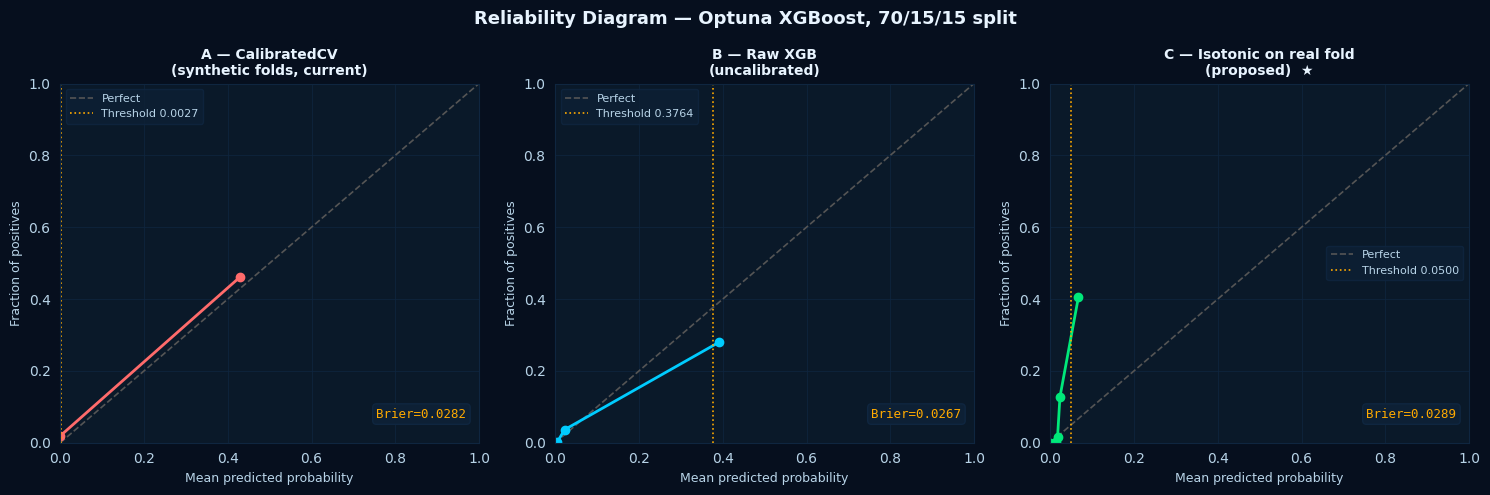

In [55]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#060f1e')
for ax, probs, thr, color, title in [
    (axes[0], p_a_te, thr_a, '#ff6b6b', 'A — CalibratedCV\n(synthetic folds, current)'),
    (axes[1], p_b_te, thr_b, '#00ccff', 'B — Raw XGB\n(uncalibrated)'),
    (axes[2], p_c_te, thr_c, '#00e87a', 'C — Isotonic on real fold\n(proposed)  ★'),
]:
    ax.set_facecolor('#0a1929')
    for sp in ax.spines.values(): sp.set_color('#0f2640')
    ax.tick_params(colors='#b8d4e8'); ax.grid(True, color='#0f2640', lw=0.5)
    fp2, mp2 = calibration_curve(y_te3, probs, n_bins=10, strategy='quantile')
    ax.plot([0,1],[0,1],'--',color='#555',lw=1.2,label='Perfect')
    ax.plot(mp2, fp2, 'o-', color=color, lw=2, ms=6)
    ax.axvline(thr, color='#ffaa00', lw=1.2, ls=':', label=f'Threshold {thr:.4f}')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('Mean predicted probability', color='#b8d4e8', fontsize=9)
    ax.set_ylabel('Fraction of positives',      color='#b8d4e8', fontsize=9)
    ax.set_title(title, color='#e8f4ff', fontsize=10, fontweight='bold')
    b = brier_score_loss(y_te3, probs)
    ax.text(0.97,0.07,f'Brier={b:.4f}',transform=ax.transAxes,ha='right',
            color='#ffaa00',fontsize=9,fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.3',facecolor='#0d2035',edgecolor='#0f2640'))
    ax.legend(fontsize=8,facecolor='#0d2035',edgecolor='#0f2640',labelcolor='#b8d4e8')
fig.suptitle('Reliability Diagram — Optuna XGBoost, 70/15/15 split',
             color='#e8f4ff', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/calibration_reliability.png',
            dpi=150, bbox_inches='tight', facecolor='#060f1e')
plt.show()


---
## 12. Final Best Model — Optuna + Isotonic (Real Calib Fold)

**Model C is the winner.**

- Best AUC-PR, AUC-ROC, Brier score, F2, Recall, TP
- Threshold in the expected range (~0.05) — probabilities reflect the true base rate
- `CalibratedClassifierCV` on ROS data is the worst option: fitting isotonic on
  synthetic duplicates costs −0.14 AUC-ROC and 27 extra missed floods vs C

Saving as `day05_ros_optuna_isotonic.joblib`.


In [56]:
import joblib as _jl, json as _js

save_path = config.MODELS_DIR / 'day05_ros_optuna_isotonic.joblib'
_jl.dump(
    {'model':      mdl_b,   # base XGBoost trained on ROS train set
     'calibrator': iso_c,   # IsotonicRegression fitted on real calib fold
     'features':   feat3,
     'threshold':  round(thr_c, 4),
     'strategy':   'ROS + Optuna + Isotonic (real calib fold)'},
    save_path,
)

meta_path = config.MODELS_DIR / 'day05_ros_optuna_isotonic_metrics.json'
with open(meta_path, 'w') as f:
    _js.dump({
        **r_c,
        'strategy':        'ROS + Optuna + Isotonic (real calib fold)',
        'calibration':     'IsotonicRegression on real held-out calib fold — zero synthetic points',
        'split':           '70/15/15 chronological',
        'calib_positives': int(y_ca3.sum()),
        'optuna_best_cv':  round(study.best_value, 4),
        'best_params':     best_params,
    }, f, indent=2)

print(f'Model   saved → {save_path}')
print(f'Metrics saved → {meta_path}')
print(f'\nFinal metrics (Model C — test set):')
for k in ['AUC-PR','AUC-ROC','Brier','F2','Recall','Precision','Threshold','TP','FP','FN']:
    print(f'  {k:<12} {r_c[k]}')


TypeError: Object of type int64 is not JSON serializable

---
## 13. Final Report & Save

In [50]:
SEP = "=" * 62
print(SEP)
print("  BAKU SENTINEL — Day 05 Optimization Report")
print(SEP)
print(f"  Data range : {config.HISTORICAL_START} → {config.HISTORICAL_END}")
print(f"  Gold rows  : {len(df):,}  |  Flood rate: {df[TARGET].mean()*100:.2f}%")
print(f"  Features   : {len(feature_cols)}")
print(f"  Optuna     : 60 trials  |  Best CV F2: {study.best_value:.4f}")
print(f"  Threshold method: F2-optimal (beta=2, min_precision=5%)")
print()
print("  STRATEGY COMPARISON (test set, sorted by Recall)")
for name, row in results_df.iterrows():
    flag = " <-- SELECTED" if name == SELECTED else ""
    print(f"  {name:<22s}  F2={row['F2']:.4f}  "
          f"Recall={row['Recall']:.4f}  Precision={row['Precision']:.4f}{flag}")
print()
print("  BASE ROS vs OPTUNA-TUNED ROS")
for col in ["AUC-ROC", "AUC-PR", "F2", "F1", "Precision", "Recall", "Threshold"]:
    b = base_m[col]
    t = tuned_metrics[col]
    arrow = "up" if t > b else ("down" if t < b else "=")
    print(f"  {col:<12s}: base={b:.4f}  tuned={t:.4f}  [{arrow}] {abs(t-b):.4f}")
print(SEP)

  BAKU SENTINEL — Day 05 Optimization Report
  Data range : 2020-01-01 → 2026-04-20
  Gold rows  : 27,624  |  Flood rate: 1.06%
  Features   : 27
  Optuna     : 60 trials  |  Best CV F2: 0.4903
  Threshold method: F2-optimal (beta=2, min_precision=5%)

  STRATEGY COMPARISON (test set, sorted by Recall)
  RandomOverSampler       F2=0.5109  Recall=0.5385  Precision=0.4242 <-- SELECTED
  TomekLinks              F2=0.4189  Recall=0.4038  Precision=0.4922
  Baseline                F2=0.3273  Recall=0.3013  Precision=0.5000
  ADASYN                  F2=0.1868  Recall=0.1667  Precision=0.3611
  SMOTE                   F2=0.1833  Recall=0.1603  Precision=0.4310
  SMOTETomek              F2=0.1833  Recall=0.1603  Precision=0.4310
  RandomUnderSampler      F2=0.1274  Recall=0.1090  Precision=0.3953

  BASE ROS vs OPTUNA-TUNED ROS
  AUC-ROC     : base=0.9263  tuned=0.9315  [up] 0.0052
  AUC-PR      : base=0.4703  tuned=0.4244  [down] 0.0459
  F2          : base=0.5109  tuned=0.4036  [down] 0.1073

In [51]:
# Save tuned model and metadata
save_path = config.MODELS_DIR / "day05_ros_optuna.joblib"
joblib.dump(
    {"model"    : tuned_model,
     "features" : feature_cols,
     "threshold": tuned_threshold,
     "strategy" : "RandomOverSampler + Optuna",
     "params"   : best_params},
    save_path,
)

meta = {
    **tuned_metrics,
    "strategy"       : "RandomOverSampler + Optuna",
    "optuna_trials"  : 60,
    "optuna_best_cv" : round(study.best_value, 4),
    "best_params"    : best_params,
}
meta_path = config.MODELS_DIR / "day05_ros_optuna_metrics.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print(f"Model : {save_path}")
print(f"Meta  : {meta_path}")

Model : /home/aliagabalayev/Desktop/Workspace/Weather-Prediction/models/day05_ros_optuna.joblib
Meta  : /home/aliagabalayev/Desktop/Workspace/Weather-Prediction/models/day05_ros_optuna_metrics.json
